# Strong-Precip Plot Workflow

Clean plotting workflow migrated from `notebooks/05-Visualise-strong-precip.ipynb`.

This notebook keeps the manuscript-relevant outputs only:
- Meteogram panels at precip/eriswil/flare points
- QFW log-time triptych
- Plume-path integrated panel across experiments

Update run-config in the next cell before execution.

## Inputs and Run Setup

Required inputs:
- COSMO-SPECS run root with:
  - `ensemble_output/<run_id>/3D_*.nc`
  - `ensemble_output/<run_id>/*.json`
  - `COS_in/extPar_Eriswil_<resolution>.nc`
- Utility dependencies from `src/utilities`:
  - `utilities.model_helpers.fetch_3d_data`
  - `utilities.model_helpers.convert_units_3d`
  - `utilities.namelist_metadata.update_dataset_metadata`

Run order:
1. Ensure `REMOTE_COSMO_SPECS_RUN_OUTPUT` is exported in your shell rc.
2. Update run config (`EXPERIMENTS`, `OUTPUT_DIR`, time windows).
3. Execute cells top-to-bottom.

In [1]:
from __future__ import annotations

import json
import os
from pathlib import Path
import sys

import matplotlib.dates as md
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from dask.diagnostics import ProgressBar
from matplotlib.colors import LinearSegmentedColormap, LogNorm
from matplotlib.ticker import FixedLocator, FuncFormatter, LogLocator

xr.set_options(keep_attrs=True)

REPO_ROOT = Path.cwd().resolve().parents[2]
SRC_DIR = REPO_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from utilities.model_helpers import convert_units_3d, fetch_3d_data
from utilities.namelist_metadata import update_dataset_metadata
from utilities import (
    calculate_supersaturation_ice,
    calculate_supersaturation_water,
)

# ---- Run config (edit here) ----
RUN_ROOT_ENV = "REMOTE_COSMO_SPECS_RUN_OUTPUT"
RUN_ROOT_VALUE = os.environ.get(RUN_ROOT_ENV)
if not RUN_ROOT_VALUE:
    raise EnvironmentError(
        f"Missing required environment variable: {RUN_ROOT_ENV}. "
        "Set it in ~/.zshrc (local) or ~/.bashrc (server)."
    )
RUN_ROOT = Path(RUN_ROOT_VALUE).expanduser().resolve()
OUTPUT_DIR = Path("figures")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

EXPERIMENTS = [
    {"run_id": "cs-eriswil__20260121_131528", "resolution": "50x40", "member_idx": 0, "label": "S"},
    # {"run_id": "cs-eriswil__20260127_211338", "resolution": "50x40", "member_idx": 0, "label": "A"},
    # {"run_id": "cs-eriswil__20260127_211338", "resolution": "50x40", "member_idx": 1, "label": "P"},
    # {"run_id": "cs-eriswil__20260121_131528", "resolution": "50x40", "member_idx": 1, "label": "C"},
]

POINTS = [
    {"name": "flare", "lat": 47.07425, "lon": 7.90522},
    {"name": "eriswil", "lat": 47.070522, "lon": 7.872991},
    {"name": "precip", "lat": 47.047, "lon": 7.845},
]

TIME_WINDOWS = {
    "meteogram": (np.datetime64("2023-01-25T12:30:00"), np.datetime64("2023-01-25T13:00:00")),
    "triptych": [
        (np.datetime64("2023-01-25T12:30:00"), np.datetime64("2023-01-25T12:40:00")),
        (np.datetime64("2023-01-25T12:33:00"), np.datetime64("2023-01-25T12:50:00")),
        (np.datetime64("2023-01-25T12:42:00"), np.datetime64("2023-01-25T13:10:00")),
    ],
    "plume_path": (np.datetime64("2023-01-25T12:30:00"), np.datetime64("2023-01-25T13:00:00")),
}


def make_strong_precip_cmap() -> LinearSegmentedColormap:
    return LinearSegmentedColormap.from_list(
        "strong_precip",
        ["#d9f0ff", "#5fa9dd", "#2a788e", "#7ad151", "#fde725", "#f8961e", "#9d0208"],
        N=256,
    )


STRONG_PRECIP_CMAP = make_strong_precip_cmap()

In [2]:
def load_single_experiment(exp: dict) -> tuple[dict, xr.Dataset, str]:
    run_root = RUN_ROOT / f"RUN_ERISWILL_{exp['resolution']}x100"
    model_dir = run_root / "ensemble_output" / exp["run_id"]
    extpar_file = run_root / "COS_in" / f"extPar_Eriswil_{exp['resolution']}.nc"

    nc_files = sorted(model_dir.glob("3D_*.nc"))
    if not nc_files:
        raise FileNotFoundError(f"No 3D files in {model_dir}")

    with next(model_dir.glob("*.json")).open() as f:
        meta = json.load(f)

    exp_names = [f.name.split("_")[-1].split(".")[0] for f in nc_files]
    flare_members = [n for n in exp_names if meta[n]["INPUT_ORG"]["sbm_par"]["lflare"]]
    flare_name = flare_members[exp["member_idx"]]
    flare_file = next(f for f in nc_files if flare_name in f.name)

    ds = fetch_3d_data(
        str(flare_file),
        str(extpar_file),
        meta[flare_name]["INPUT_ORG"],
        var_sets=["meteo", "bulk", "spec"],
        chunks={"time": 1},
    )
    ds = convert_units_3d(update_dataset_metadata(ds), ds["rho"]).isel(altitude=slice(80, None))

    cfg = {
        "run_id": exp["run_id"],
        "label": exp["label"],
        "resolution": "400m" if "50x40" in meta[flare_name]["domain"] else "100m",
        "flare_start_datetime": np.datetime64("2023-01-25T12:30:00"),
        "flare_particles_emitted": meta[flare_name]["INPUT_ORG"]["sbm_par"].get("n_particles", "n/a"),
        "ice_shape": meta[flare_name]["INPUT_ORG"]["sbm_par"].get("ice_shape", "n/a"),
    }
    return cfg, ds, flare_name


def prepare_reduced_fields(ds_3d: xr.Dataset) -> xr.Dataset:
    ds = ds_3d.sel(latitude=slice(None, POINTS[0]["lat"] + 0.008), longitude=slice(None, POINTS[0]["lon"] + 0.008))
    dx = float(1e3 * np.mean(np.diff(ds.longitude.values)) * 111.13295254925466)
    dy = float(1e3 * np.mean(np.diff(ds.latitude.values)) * 111.13295254925466)
    gridcell = ds["rho"] * dx * dy
    ds = ds.copy()
    ds["u"] = ds["ut"] / gridcell
    ds["v"] = ds["vt"] / gridcell
    ds["w"] = ds["wt"] / gridcell
    ds["qiqs"] = ds["qi"] + ds["qs"]
    return ds


def prepare_meteogram_points(ds_reduced: xr.Dataset) -> xr.Dataset:
    coord_selection = {
        "latitude": [p["lat"] for p in POINTS],
        "longitude": [p["lon"] for p in POINTS],
    }
    ds = ds_reduced.sel(coord_selection, method="nearest")
    ds["qiqs"] = xr.where(ds["qi"] + ds["qs"] > 1e-10, ds["qi"] + ds["qs"], np.nan)
    ds["S_ice"] = calculate_supersaturation_ice(ds["t"], ds["qv"] / 1000)
    ds["S_water"] = calculate_supersaturation_water(ds["t"], ds["qv"] / 1000)
    ds["cdnc"].attrs["units"] = "cm^-3"
    ds["icnc"].attrs["units"] = "L^-1"
    ds["S_ice"].attrs["units"] = "%"
    ds["S_water"].attrs["units"] = "%"
    return ds

In [3]:
def format_datetime_axis(ax, t0: np.datetime64, t1: np.datetime64, major_min: int = 5, minor_min: int = 1) -> None:
    duration = int((t1 - t0) / np.timedelta64(1, "m"))
    major_times = np.arange(0, duration + major_min, major_min)
    minor_times = np.arange(0, duration + minor_min, minor_min)
    major_pos = [md.date2num(t0 + np.timedelta64(int(t), "m")) for t in major_times]
    minor_pos = [md.date2num(t0 + np.timedelta64(int(t), "m")) for t in minor_times]
    ax.xaxis.set_major_locator(FixedLocator(major_pos))
    ax.xaxis.set_minor_locator(FixedLocator(minor_pos))
    ax.set_xticklabels([f"+{int(t):02d}" for t in major_times])
    ax.tick_params(axis="x", which="major", direction="out", length=7)
    ax.tick_params(axis="x", which="minor", direction="out", length=4)
    ax.tick_params(which="both", direction="out", top=True, right=True)
    ax.minorticks_on()
    ax.grid(True, which="major", linestyle="--", linewidth=0.25, color="black", alpha=0.6)
    ax.grid(True, which="minor", linestyle=":", linewidth=0.15, color="black", alpha=0.35)


def add_time_elapsed_coord(da: xr.DataArray, t0: np.datetime64) -> xr.DataArray:
    elapsed = (da.time.values - np.datetime64(t0)) / np.timedelta64(1, "m")
    return da.assign_coords(time_elapsed=("time", elapsed))


def log_axis_params(t_start: np.datetime64, t_end: np.datetime64) -> tuple[float, float, float, np.ndarray]:
    x_min = 0.07
    x_max = float((t_end - t_start) / np.timedelta64(1, "m"))
    span = x_max - x_min
    major = np.array([0.1, 1, 2, 5, 10]) if span <= 10 else np.array([0.1, 1, 2, 5, 10, 20, 50])
    if span > 60:
        major = np.array([0.1, 1, 5, 10, 30, 60, 120])
    return x_min, x_max, span, major


def format_log_elapsed_axis(ax, t_start: np.datetime64, t_end: np.datetime64, ylim: tuple[float, float]) -> tuple[float, float]:
    x_min, x_max, span, major_locs = log_axis_params(t_start, t_end)
    ax.set_xscale("log")
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(*ylim)
    ax.xaxis.set_major_locator(FixedLocator([m for m in major_locs if x_min <= m <= x_max]))
    ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=range(1, 10)))
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.1f}".rstrip("0").rstrip(".") if x < 1 else f"{x:.0f}" if span <= 60 else f"{x/60:.1f}h"))
    ax.set_xlabel("elapsed time / (min)")
    ax.tick_params(which="both", direction="out", top=True, right=True)
    ax.grid(True, which="major", linestyle="--", linewidth=0.25, alpha=0.6)
    ax.grid(True, which="minor", linestyle=":", linewidth=0.15, alpha=0.35)
    return x_min, x_max


def plot_meteogram(ds_in: xr.Dataset, wind: xr.Dataset, points: list[dict]) -> tuple[plt.Figure, np.ndarray]:
    panel_vars = ["w", "qi", "qc", "qs", "cdnc", "icnc", "S_ice", "S_water"]
    n_points = len(points)
    fig, axes = plt.subplots(len(panel_vars), n_points, figsize=(4.6 * n_points, 19), constrained_layout=True)
    axes = np.atleast_2d(axes)

    for col_idx, point in enumerate(points):
        ds_point = ds_in.isel(latitude=col_idx, longitude=col_idx)
        wind_point = wind.isel(latitude=col_idx, longitude=col_idx)

        for row_idx, var in enumerate(panel_vars):
            ax = axes[row_idx, col_idx]
            cmap = "RdBu_r" if var in {"w", "S_ice", "S_water"} else STRONG_PRECIP_CMAP
            kwargs = {"vmin": -0.05, "vmax": 0.05} if var == "w" else {}

            ds_point[var].plot(
                x="time",
                ax=ax,
                cmap=cmap,
                alpha=0.9,
                robust=var not in {"w", "S_ice", "S_water"},
                add_colorbar=False,
                **kwargs,
            )
            q = wind_point.plot.quiver(
                ax=ax,
                y="altitude",
                x="time",
                u="dw",
                v="w",
                hue="w",
                cmap="RdBu_r",
                vmin=-0.05,
                vmax=0.05,
                scale=3,
                alpha=0.8,
                edgecolor="white",
                linewidth=0.2,
                cbar_ax=None,
                add_guide=False,
            )
            if q.colorbar is not None:
                q.colorbar.remove()

            format_datetime_axis(ax, ds_point.time.values[0], ds_point.time.values[-1])
            if row_idx == 0:
                ax.set_title(point["name"], fontsize=11)
            else:
                ax.set_title("")
            if col_idx == 0:
                ax.set_ylabel(var)
            else:
                ax.set_ylabel("")
            ax.set_xlabel("")

    return fig, axes

In [4]:
def prepare_plume_data(ds: xr.Dataset, variable: str, zlim: tuple[float, float]) -> xr.DataArray:
    da = xr.where(ds[variable] > zlim[0], ds[variable], np.nan)
    if "cell" in da.dims:
        da = da.sum("cell")
    if "altitude" in da.dims:
        da = da.max("altitude")
    return da


def plot_qfw_triptych(ds_meteos: xr.Dataset, windows: list[tuple[np.datetime64, np.datetime64]]) -> Path:
    fig, axes = plt.subplots(1, 3, figsize=(18, 4), constrained_layout=True)
    for i, (t_start, t_end) in enumerate(windows):
        ds_sum = ds_meteos.isel(latitude=2 - i, longitude=2 - i).sum("altitude")
        ds_sum = add_time_elapsed_coord(ds_sum, t_start)
        ds_sum["qfw"].plot(
            ax=axes[i],
            x="time_elapsed",
            y="diameter",
            yscale="log",
            cmap=STRONG_PRECIP_CMAP,
            norm=LogNorm(vmin=1e-8, vmax=1e-3),
            add_colorbar=(i == 2),
        )
        x_min, x_max = format_log_elapsed_axis(axes[i], t_start, t_end, (1, 1e3))
        axes[i].plot([x_min, x_max], [100, 100], "--", lw=0.75, color="black", alpha=0.7)
        axes[i].plot([x_min, x_max], [500, 500], "--", lw=0.75, color="black", alpha=0.7)
        if i > 0:
            axes[i].set_ylabel("")
    out = OUTPUT_DIR / "strong_precip_qfw_logtime_triptych.png"
    fig.savefig(out, dpi=300, bbox_inches="tight")
    plt.close(fig)
    return out


def plot_plume_path_panel(
    cfg_list: list[dict],
    plume_list: list[xr.DataArray],
    variable: str = "nf",
) -> Path:
    fig, axes = plt.subplots(1, len(plume_list), figsize=(4.4 * len(plume_list), 3.4), constrained_layout=True)
    axes = np.atleast_1d(axes)
    pmesh = None
    t_start, t_end = TIME_WINDOWS["plume_path"]

    for idx, (ax, cfg, da) in enumerate(zip(axes, cfg_list, plume_list, strict=True)):
        da = add_time_elapsed_coord(da, t_start)
        print(f'debugging:: {da.sizes}')
        pmesh = da.plot(
            ax=ax,
            x="time_elapsed",
            y="diameter",
            yscale="log",
            cmap=STRONG_PRECIP_CMAP,
            norm=LogNorm(vmin=1e-2, vmax=1e4),
            add_colorbar=False,
            alpha=0.95,
        )
        x_min, x_max = format_log_elapsed_axis(ax, t_start, t_end, (1, 1e3))
        ax.plot([x_min, x_max], [100, 100], "--", lw=0.75, color="black", alpha=0.7)
        ax.plot([x_min, x_max], [500, 500], "--", lw=0.75, color="black", alpha=0.7)
        ax.text(
            0.02, 0.98, f"({chr(65 + idx)}) {cfg['label']}",
            transform=ax.transAxes, ha="left", va="top", fontsize=11, fontweight="semibold"
        )
        if idx > 0:
            ax.set_ylabel("")

    fig.colorbar(pmesh, ax=axes, pad=0.02, aspect=30, label=f"integrated {variable} per bin")

    return fig, axes

## Data Loading and Reduction

Run this cell after updating the run configuration.

What it does:
1. Loads selected COSMO-SPECS 3D members.
2. Builds reduced fields for diagnostics.
3. Materializes reused data (`meteos`, `wind`) with progress feedback for faster downstream plotting.

In [5]:
cfgs: list[dict] = []
ds_3d_list: list[xr.Dataset] = []
flare_names: list[str] = []

for exp in EXPERIMENTS:
    cfg, ds_3d, flare_name = load_single_experiment(exp)
    cfgs.append(cfg)
    ds_3d_list.append(ds_3d)
    flare_names.append(flare_name)

print("Loaded flare members:", flare_names)

# Primary reference run for meteogram diagnostics.
reference_ds = prepare_reduced_fields(ds_3d_list[0])

# Keep only what plotting actually needs, then materialize once in memory.
meteogram_vars = ["w", "qi", "qc", "qs", "cdnc", "icnc", "S_ice", "S_water", "qfw", "t", "qv"]
with ProgressBar():
    meteos = prepare_meteogram_points(reference_ds)[meteogram_vars].load()

# Wind is reused across 3 meteogram figures.
wind = meteos.isel(time=slice(None, None, 5)).copy()
wind["dw"] = wind["w"].diff("time").reindex(time=wind.time, fill_value=np.nan)
with ProgressBar():
    wind = wind[["dw", "w"]].load()

print("Reference dataset sizes:", dict(meteos.sizes))

Loaded flare members: ['20260121131550']
[########################################] | 100% Completed | 106.61 s
Reference dataset sizes: {'time': 229, 'altitude': 20, 'latitude': 3, 'longitude': 3, 'diameter': 66}


## Meteogram and Triptych Exports

This cell writes the meteogram panels and QFW triptych.

Standard output names:
- `strong_precip_meteogram_all_points.png`
- `strong_precip_qfw_logtime_triptych.png`

Verify that files are written under `figures/` after execution.

Saved files:
 - /home/b/b382237/code/polarcap/python/polarcap_analysis/notebooks/legacy_figures/strong_precip/figures/strong_precip_meteogram_all_points.png
 - /home/b/b382237/code/polarcap/python/polarcap_analysis/notebooks/legacy_figures/strong_precip/figures/strong_precip_qfw_logtime_triptych.png


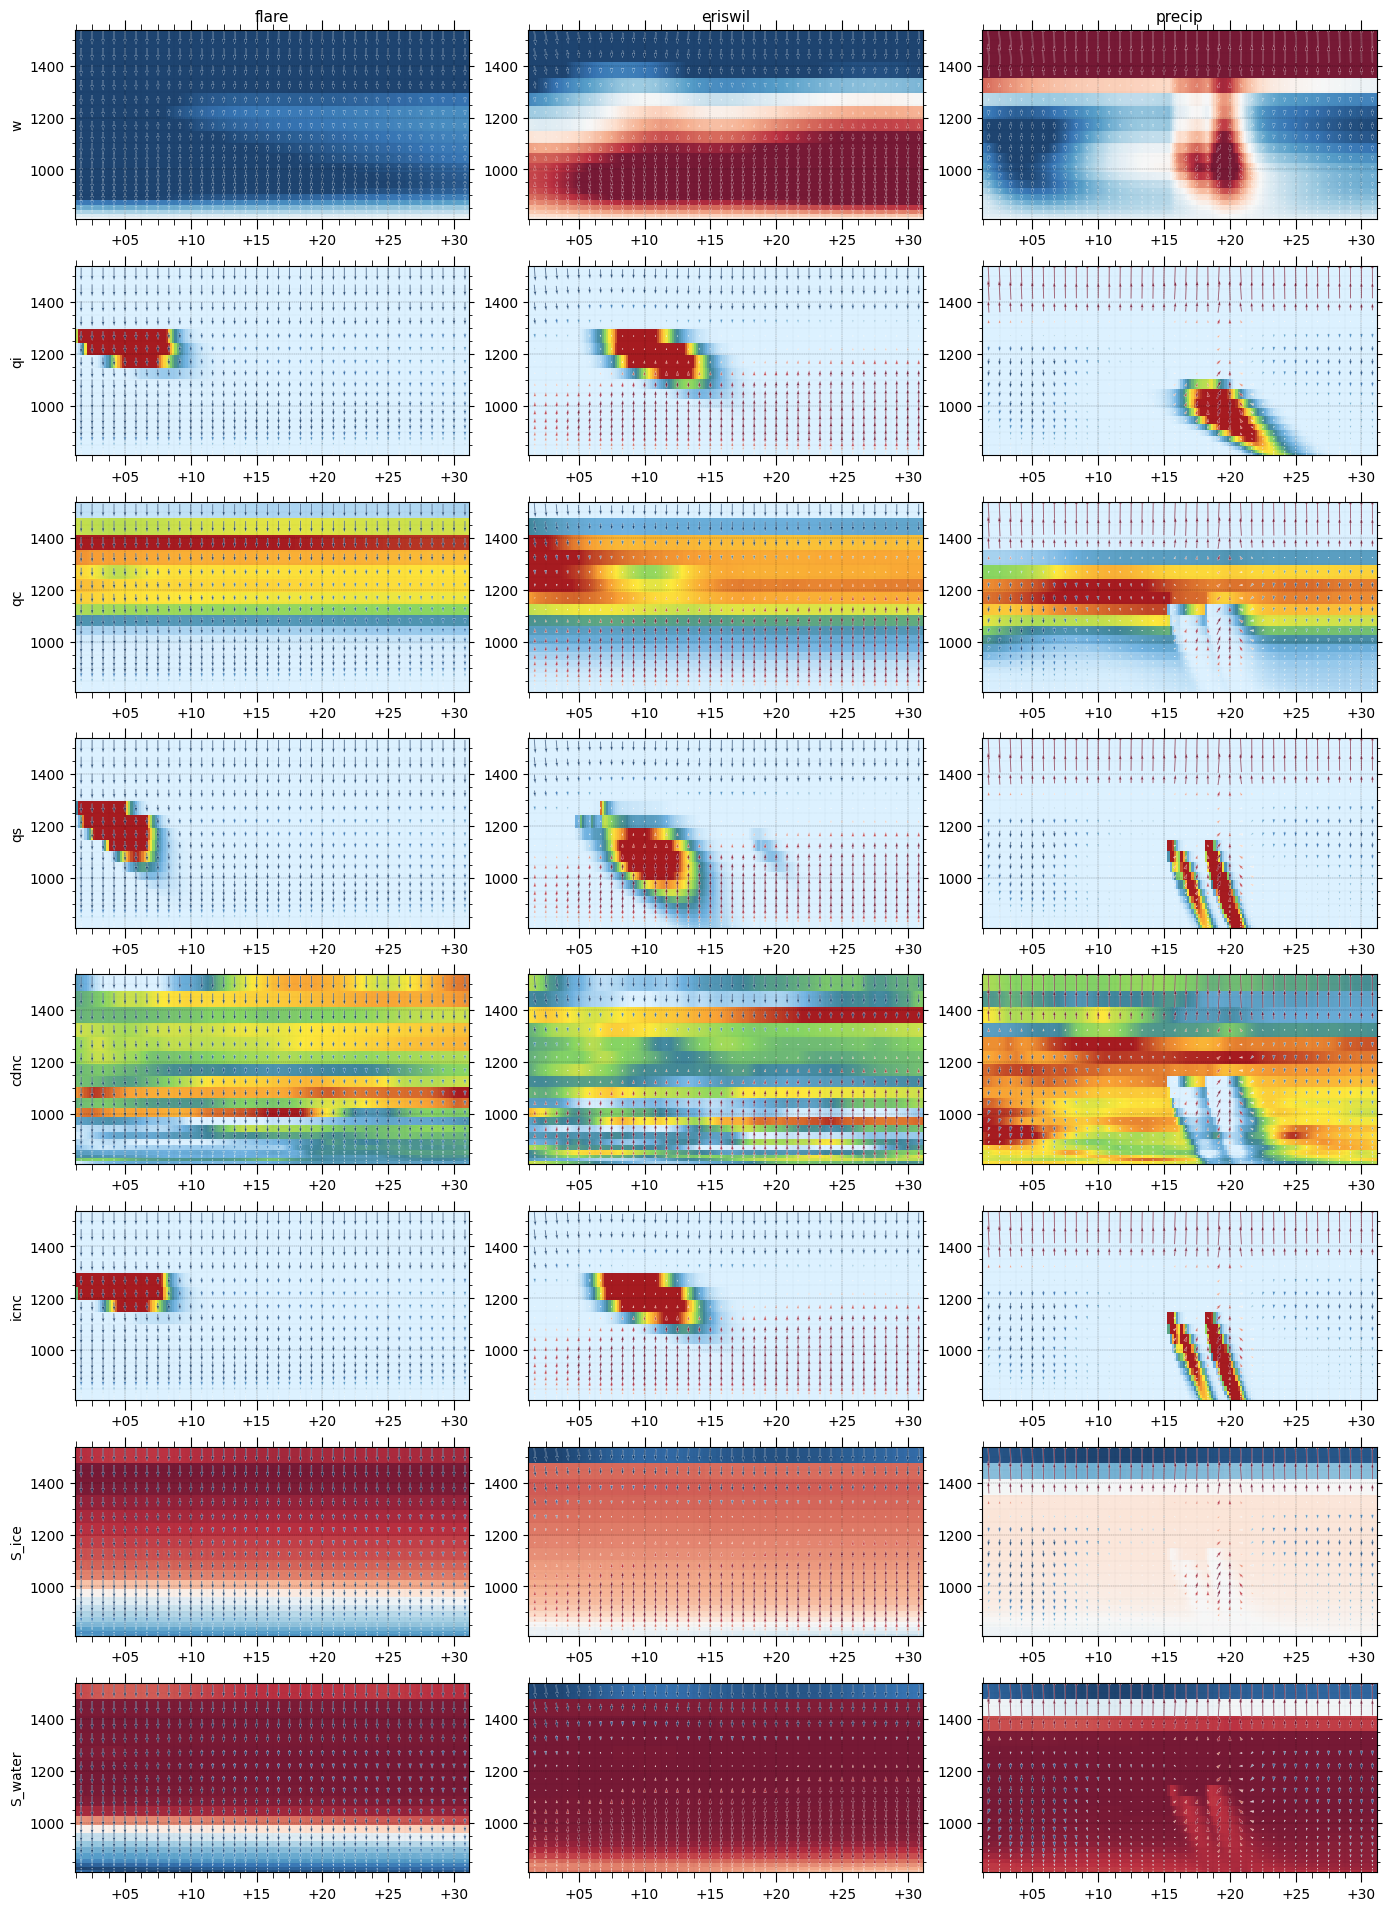

In [10]:
t0, t1 = TIME_WINDOWS["meteogram"]

saved = []
fig, axes = plot_meteogram(meteos, wind, POINTS)
for ax in axes.flat:
    ax.set_xlim(t0, t1)
out = OUTPUT_DIR / "strong_precip_meteogram_all_points.png"
fig.savefig(out, dpi=300, bbox_inches="tight")
# plt.close(fig)
saved.append(out)

saved.append(plot_qfw_triptych(meteos, TIME_WINDOWS["triptych"]))
print("Saved files:")
for f in saved:
    print(" -", f.resolve())

In [7]:
import dask
# New helper cell (before plot_plume_path_panel call)
t_start, t_end = TIME_WINDOWS["plume_path"]

delayed_list = []
for coords in POINTS:
    meteo_nf = [ prepare_plume_data(ds, variable="nf", zlim=(1e-2, 1e4))
        .sel(latitude=coords["lat"], longitude=coords["lon"], method="nearest")
        .sel(time=slice(t_start, t_end))
        .isel(diameter=slice(30, None))
        for ds in ds_3d_list
        ]
    delayed_list.append(meteo_nf)
    
with ProgressBar():
    ds_meteo_list = dask.compute( delayed_list )

[########################################] | 100% Completed | 34.12 s


## Plume-Path Panel Notes

This section prepares and renders plume-path panels for manuscript diagnostics.

Expected output name:
- `strong_precip_plume_path_<variable>.png`

Notes:
- Output paths are local and relative to this notebook (`figures/`).
- Heavy loading remains lazy until compute/materialization is triggered.
- For Dask/SLURM diagnostics and scaling strategies, see `src/utilities/README.md`.

In [8]:
variable = "nf"
saved = []
for i, da in enumerate(ds_meteo_list[0]):
    fig, axes = plot_plume_path_panel(cfgs, da, variable)
    out = OUTPUT_DIR / f"strong_precip_plume_path_{variable}.png"
    fig.savefig(out, dpi=300, bbox_inches="tight")
    plt.close(fig)
    saved.append(out)
    
    
for f in saved:
    print(" -", f.resolve())

debugging:: Frozen({'time': 181, 'diameter': 36})
debugging:: Frozen({'time': 181, 'diameter': 36})
debugging:: Frozen({'time': 181, 'diameter': 36})
 - /home/b/b382237/code/polarcap/python/polarcap_analysis/notebooks/legacy_figures/strong_precip/figures/strong_precip_plume_path_nf.png
 - /home/b/b382237/code/polarcap/python/polarcap_analysis/notebooks/legacy_figures/strong_precip/figures/strong_precip_plume_path_nf.png
 - /home/b/b382237/code/polarcap/python/polarcap_analysis/notebooks/legacy_figures/strong_precip/figures/strong_precip_plume_path_nf.png


In [9]:
plt.show()